In [1]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt

Polynomial Coefficients:  [2.09218103 1.58837751 0.60606342]


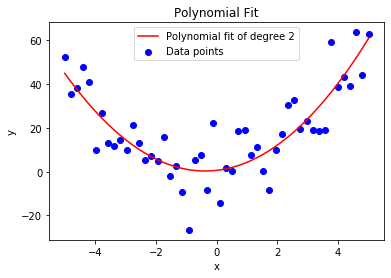

In [2]:
# Step 1: Generate some sample data
# Creating data points that roughly follow a quadratic curve
np.random.seed(0)
x = np.linspace(-5, 5, 50) # 50 points between -5 and 5
y = 2 * x**2 + 3 * x + np.random.randn(50) * 10 # y = 2x^2 + 3x + some noise

# Step 2: Polynomial fitting using NumPy's polyfit
# Fit a 2nd degree polynomial to the data
degree = 2 # Degree of the polynomial
coefficients = np.polyfit(x, y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Step 3: Use the coefficients to predict y-values (polynomial function)
# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)
# Generate predicted y-values based on the fitted polynomial
y_pred = polynomial(x)

# Step 4: Plotting the results
plt.scatter(x, y, color='blue', label='Data points') # Original data points
plt.plot(x, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title('Polynomial Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [3]:
# Mean Squared Error (MSE)
mse = np.mean((y - y_pred)**2)
print(f'Mean Squared Error: {mse:.4f}')

Mean Squared Error: 108.8860


In [4]:
# R-squared value
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_pred)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squared:.4f}')

R-squared: 0.7236


## Challenge 10A

In [5]:
def analysis(Y, Y_pred):
    mse = np.mean((Y - Y_pred)**2)
    ss_total = np.sum((Y - np.mean(Y))**2)
    ss_res = np.sum((Y - Y_pred)**2)
    r_squared = 1 - (ss_res / ss_total)
    return mse, r_squared

In [6]:
def polyfit(X, Y, degree, X_line):
    coefficients = np.polyfit(X, Y, degree)
    print("Poly Fit \nPolynomial Coefficients: ", coefficients)

    polynomial = np.poly1d(coefficients)
    Y_polpred = polynomial(X_line)
    Y_polpoints = polynomial(X)
    
    return Y_polpred, Y_polpoints

In [7]:
def plot():
    # Plots

    plt.scatter(X, Y, color='blue', label='Data points')
    plt.plot(X_line, Y_sqpred, color='green', label='Least squares')
    plt.plot(X_line, Y_polpred, color='red', label=f'Polynomial fit of degree {degree}')
    # Fitted curve
    plt.title('Least Sq vs Poly Fit')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()

In [8]:
# Setup

rng = np.random.default_rng()

X = rng.random(5) * 5
X = np.sort(X)
Y = rng.random(5) * 5

X_line = np.linspace(X.min(), X.max(), 100)

A = np.vstack([X, np.ones(len(X))]).T

In [9]:
# Least squares

m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
Y_sqpred = X_line * m + c
Y_sqpoints = X * m + c

print(f"Least Squares\nSlope: {m}, Intercept: {c}")



mse, r_squared = analysis(Y, Y_sqpoints)
print(f'Mean Squared Error: {mse:.4f}')
print(f'R-squared: {r_squared:.4f}')
mse_sq = mse
r_squared_sq = r_squared

Least Squares
Slope: 0.2648744317480329, Intercept: 2.5094269470257644
Mean Squared Error: 1.0437
R-squared: 0.1708


Poly Fit 
Polynomial Coefficients:  [-0.1610999   0.83160922 -0.45241414  2.64129791]
Mean Squared Error: 0.9989
R-squared: 0.2064


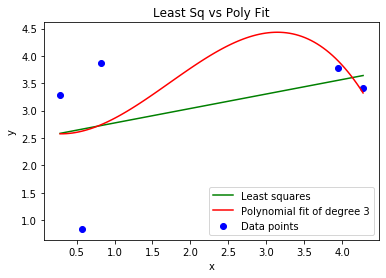

In [10]:
# Degree 3 Polyfit

degree = 3
Y_polpred, Y_polpoints = polyfit(X, Y, degree, X_line)

mse, r_squared = analysis(Y, Y_polpoints)
print(f'Mean Squared Error: {mse:.4f}')
print(f'R-squared: {r_squared:.4f}')
mse_poly3 = mse
r_squared_poly3 = r_squared

plot()

In [11]:
if (mse_sq > mse_poly3): best_fit = "Degree 3 Polynomial"
else: best_fit = "Least Squares"
print(f'Based off MSE and R^2 (which are proportional), the {best_fit} is the best fit.')

Based off MSE and R^2 (which are proportional), the Degree 3 Polynomial is the best fit.


## Challenge 10B
Cranking up (crank that soulja boy)

Poly Fit 
Polynomial Coefficients:  [  3.07114804 -28.65323843  80.20830827 -61.88233932  15.0018562 ]
Mean Squared Error: 0.0000
R-squared: 1.0000


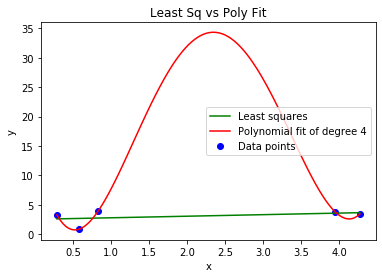

In [12]:
# Degree 4 Polyfit

degree = 4
Y_polpred, Y_polpoints = polyfit(X, Y, degree, X_line)

mse, r_squared = analysis(Y, Y_polpoints)
print(f'Mean Squared Error: {mse:.4f}')
print(f'R-squared: {r_squared:.4f}')

plot()

Poly Fit 
Polynomial Coefficients:  [  0.52238559  -2.10371763 -12.14896741  61.54542342 -53.6159298
  13.81499362]
Mean Squared Error: 0.0000
R-squared: 1.0000


<ipython-input-13-e690ab231cf2>:4: RankWarning: Polyfit may be poorly conditioned
  Y_polpred, Y_polpoints = polyfit(X, Y, degree, X_line)


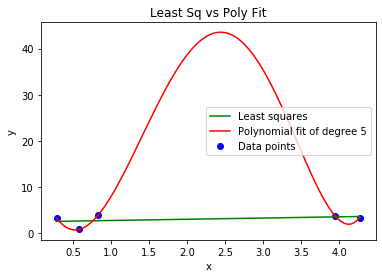

In [13]:
# Degree 5 Polyfit (violating the rule of thumb)

degree = 5
Y_polpred, Y_polpoints = polyfit(X, Y, degree, X_line)

mse, r_squared = analysis(Y, Y_polpoints)
print(f'Mean Squared Error: {mse:.4f}')
print(f'R-squared: {r_squared:.4f}')


plot()

<ipython-input-14-b6be88653cc6>:4: RankWarning: Polyfit may be poorly conditioned
  Y_polpred, Y_polpoints = polyfit(X, Y, degree, X_line)


Poly Fit 
Polynomial Coefficients:  [  0.09376849  -0.11526128  -2.02632186  -6.29738076  52.62417733
 -49.22022185  13.15328512]
Mean Squared Error: 0.0000
R-squared: 1.0000


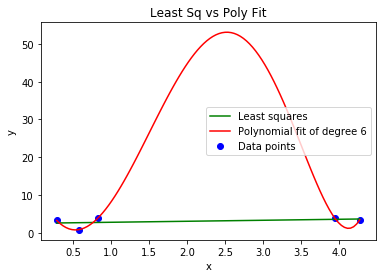

In [14]:
# Degree 6 Polyfit (violating the rule of thumb)

degree = 6
Y_polpred, Y_polpoints = polyfit(X, Y, degree, X_line)

mse, r_squared = analysis(Y, Y_polpoints)
print(f'Mean Squared Error: {mse:.4f}')
print(f'R-squared: {r_squared:.4f}')


plot()

Cranking it down

Poly Fit 
Polynomial Coefficients:  [-0.15954986  1.00583794  2.15649426]
Mean Squared Error: 1.0308
R-squared: 0.1810


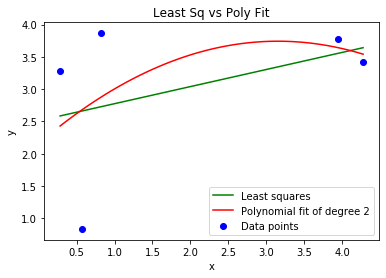

In [15]:
# Degree 2 Polyfit

degree = 2
Y_polpred, Y_polpoints = polyfit(X, Y, degree, X_line)

mse, r_squared = analysis(Y, Y_polpoints)
print(f'Mean Squared Error: {mse:.4f}')
print(f'R-squared: {r_squared:.4f}')


plot()

Poly Fit 
Polynomial Coefficients:  [0.26487443 2.50942695]
Mean Squared Error: 1.0437
R-squared: 0.1708


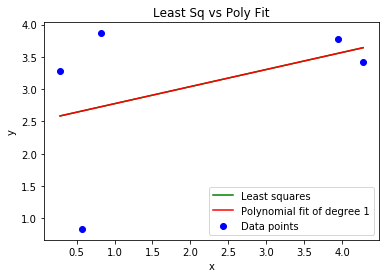

In [16]:
# Degree 1 Polyfit

degree = 1
Y_polpred, Y_polpoints = polyfit(X, Y, degree, X_line)

mse, r_squared = analysis(Y, Y_polpoints)
print(f'Mean Squared Error: {mse:.4f}')
print(f'R-squared: {r_squared:.4f}')


plot()

## Challenge 10C

In [17]:
def create_vandermonde_matrix(X, degree):
    V = np.vander(X, N=degree+1, increasing=True)
    return V

def solve_coefficients(V, Y):
    VT_V = np.dot(V.T, V)
    VT_Y = np.dot(V.T, Y)
    coefficients = np.linalg.solve(VT_V, VT_Y)
    return coefficients

def vanfit(X, Y, coefficients, X_line):
    print("Vandermonde Fit \nPolynomial Coefficients: ", coefficients)

    polynomial = np.poly1d(coefficients[::-1])
    Y_polpred = polynomial(X_line)
    Y_polpoints = polynomial(X)
    
    return Y_polpred, Y_polpoints

Vandermonde Fit 
Polynomial Coefficients:  [ 15.00185621 -61.88233935  80.20830832 -28.65323844   3.07114804]
Mean Squared Error: 0.0000
R-squared: 1.0000


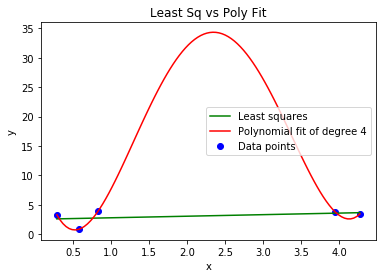

In [18]:
# Degree 4 Vandermonde

degree = 4
V = create_vandermonde_matrix(X, degree)
coefficients = solve_coefficients(V, Y)
Y_polpred, Y_polpoints = vanfit(X, Y, coefficients, X_line)

mse, r_squared = analysis(Y, Y_polpoints)
print(f'Mean Squared Error: {mse:.4f}')
print(f'R-squared: {r_squared:.4f}')


plot()